In [1]:
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

DATA_PATH = "../data/processed/employee_attrition_cleaned.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [2]:
print(df.shape)
print(df.info())

(1470, 31)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null 

## Step 1 — Contingency table

In [3]:
table = pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

table

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


## Step 2 — Row percentages

In [4]:
row_percentages = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

row_percentages

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


## Perform the chi-square test

In [5]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p)

Chi-square statistic: 87.56429365828768
Degrees of freedom: 1
p-value: 8.15842372153832e-21


In [6]:
expected

array([[884.06938776, 169.93061224],
       [348.93061224,  67.06938776]])

## Effect size — Cramér's V

In [7]:
n = table.to_numpy().sum()

r, c = table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, c - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.24406463632881792


## RQ2 — Job role and attrition

In [8]:
table = pd.crosstab(
    df["JobRole"],
    df["Attrition"]
)

table

Attrition,No,Yes
JobRole,,
Healthcare Representative,122,9
Human Resources,40,12
Laboratory Technician,197,62
Manager,97,5
Manufacturing Director,135,10
Research Director,78,2
Research Scientist,245,47
Sales Executive,269,57
Sales Representative,50,33


In [9]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 86.19025367670434
p-value: 2.7524816380506575e-15


In [10]:
expected

array([[109.87959184,  21.12040816],
       [ 43.61632653,   8.38367347],
       [217.24285714,  41.75714286],
       [ 85.55510204,  16.44489796],
       [121.62244898,  23.37755102],
       [ 67.10204082,  12.89795918],
       [244.92244898,  47.07755102],
       [273.44081633,  52.55918367],
       [ 69.61836735,  13.38163265]])

## RQ3 — Department and attrition

In [11]:
table = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 10.79600732241067
p-value: 0.004525606574479633


In [12]:
table = pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"]
)

table

Attrition,No,Yes
JobSatisfaction,,
1,223,66
2,234,46
3,369,73
4,407,52


In [13]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 17.505077010348
p-value: 0.0005563004510387556


## check distributions

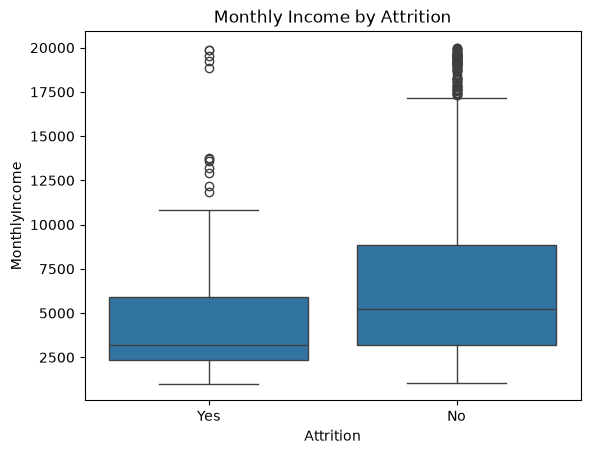

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.show()

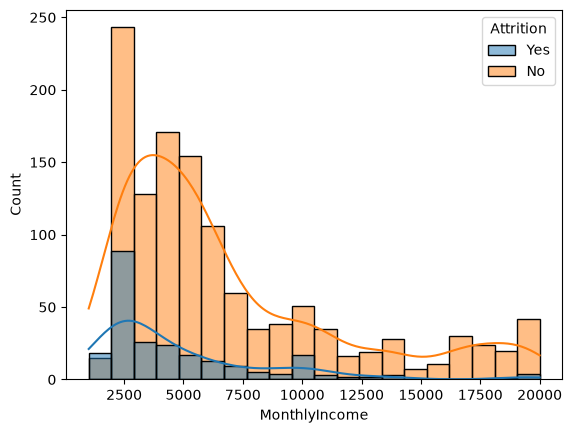

In [15]:
sns.histplot(
    data=df,
    x="MonthlyIncome",
    hue="Attrition",
    kde=True
)

plt.show()

## Welch's t-test

In [16]:
stayed_income = df.loc[
    df["Attrition"] == "No",
    "MonthlyIncome"
]

left_income = df.loc[
    df["Attrition"] == "Yes",
    "MonthlyIncome"
]

result = stats.ttest_ind(
    stayed_income,
    left_income,
    equal_var=False
)

print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)

t-statistic: 7.482621586644742
p-value: 4.433588628286069e-13


## Mann–Whitney U test

In [17]:
result = stats.mannwhitneyu(
    stayed_income,
    left_income,
    alternative="two-sided"
)

print("U statistic:", result.statistic)
print("p-value:", result.pvalue)

U statistic: 191600.5
p-value: 2.9508309172888725e-14


Repeat for Age

In [18]:
stayed_age = df.loc[
    df["Attrition"] == "No",
    "Age"
]

left_age = df.loc[
    df["Attrition"] == "Yes",
    "Age"
]

result = stats.ttest_ind(
    stayed_age,
    left_age,
    equal_var=False
)

print(result)

TtestResult(statistic=np.float64(5.82801185398895), pvalue=np.float64(1.37976006494398e-08), df=np.float64(316.93111237533554))


Repeat for YearsAtCompany

In [19]:
stayed_tenure = df.loc[
    df["Attrition"] == "No",
    "YearsAtCompany"
]

left_tenure = df.loc[
    df["Attrition"] == "Yes",
    "YearsAtCompany"
]

result = stats.ttest_ind(
    stayed_tenure,
    left_tenure,
    equal_var=False
)

print(result)

TtestResult(statistic=np.float64(5.282596058921782), pvalue=np.float64(2.2859051752725086e-07), df=np.float64(338.21310100287695))


Repeat for DistanceFromHome


In [20]:
stayed_tenure = df.loc[
    df["Attrition"] == "No",
    "DistanceFromHome"
]

left_tenure = df.loc[
    df["Attrition"] == "Yes",
    "DistanceFromHome"
]

result = stats.ttest_ind(
    stayed_tenure,
    left_tenure,
    equal_var=False
)

print(result)

TtestResult(statistic=np.float64(-2.888183062817627), pvalue=np.float64(0.0041365119715114085), df=np.float64(322.7242793667992))


## Correlation analysis

In [21]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr(method="pearson")

correlation

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,...,0.001904,0.053535,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,...,0.000473,0.007846,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,...,0.027110,0.006557,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,...,-0.024539,-0.009118,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,...,-0.029548,0.007665,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999
HourlyRate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,...,-0.002172,0.001330,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,...,-0.029071,0.034297,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976
JobLevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,...,-0.021222,0.021642,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,...,0.002297,-0.012454,0.010690,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.027656
MonthlyIncome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,...,-0.017120,0.025873,0.005408,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.344079


Spearman correlation

In [22]:
spearman = numeric_df.corr(method="spearman")

spearman

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.007290,-0.019291,0.204937,0.009820,0.028858,0.034456,0.489618,-0.005185,0.471902,...,0.000093,0.046063,0.056633,0.656896,0.000316,-0.003707,0.251686,0.197978,0.173647,0.194818
DailyRate,0.007290,1.000000,-0.002754,-0.013607,0.018961,0.023511,0.042469,0.003816,0.027829,0.016260,...,0.000624,0.009685,0.038514,0.020951,-0.011339,-0.040352,-0.009778,0.007208,-0.037631,-0.004717
DistanceFromHome,-0.019291,-0.002754,1.000000,0.015708,-0.010401,0.020446,0.034430,0.022148,-0.013078,0.002512,...,0.011320,0.005852,0.030190,-0.002912,-0.024848,-0.020402,0.010513,0.013708,-0.004685,0.004448
Education,0.204937,-0.013607,0.015708,1.000000,-0.027625,0.014432,0.037231,0.107419,-0.005175,0.120028,...,-0.025081,-0.013173,0.013794,0.162177,-0.023749,0.017350,0.064196,0.054567,0.032203,0.051292
EnvironmentSatisfaction,0.009820,0.018961,-0.010401,-0.027625,1.000000,-0.052380,-0.015301,-0.000192,-0.002993,-0.015163,...,-0.029160,0.005353,0.009826,-0.013882,-0.011659,0.027169,0.008425,0.020140,0.026082,-0.001732
HourlyRate,0.028858,0.023511,0.020446,0.014432,-0.052380,1.000000,0.043884,-0.033876,-0.068340,-0.019762,...,-0.002185,0.000259,0.050543,-0.012072,0.000292,-0.010003,-0.029032,-0.034016,-0.052412,-0.013811
JobInvolvement,0.034456,0.042469,0.034430,0.037231,-0.015301,0.043884,1.000000,-0.018424,-0.012148,-0.024552,...,-0.024733,0.037857,0.034464,0.006444,0.002014,-0.019889,0.013836,0.015548,-0.008307,0.037397
JobLevel,0.489618,0.003816,0.022148,0.107419,-0.000192,-0.033876,-0.018424,1.000000,-0.000852,0.920429,...,-0.018608,0.011311,0.047786,0.734678,-0.019729,0.040466,0.472283,0.391085,0.269096,0.370889
JobSatisfaction,-0.005185,0.027829,-0.013078,-0.005175,-0.002993,-0.068340,-0.012148,-0.000852,1.000000,0.004881,...,0.006979,-0.014679,0.012785,-0.015875,-0.011681,-0.029781,0.012280,0.000531,0.007497,-0.016772
MonthlyIncome,0.471902,0.016260,0.002512,0.120028,-0.015163,-0.019762,-0.024552,0.920429,0.004881,1.000000,...,-0.026999,0.003885,0.045852,0.710024,-0.034847,0.030759,0.464315,0.394712,0.264599,0.365386
